# 🧠 Deep Invertible Reinforcement Learning (DIRL) for WPA3 Intrusion Detection

---

## 📌 What is DIRL?

**DIRL** stands for **Deep Invertible Reinforcement Learning** — a hybrid framework combining:

- 🔁 **Invertible Neural Networks (INNs)**: Deep learning models where forward and inverse mappings are bijective and differentiable. These are useful for learning interpretable, reversible, and density-aware latent representations.
- 🎯 **Reinforcement Learning (RL)**: A paradigm in which agents learn to make decisions by maximizing a reward signal in an environment. In DIRL, RL can be integrated explicitly or implicitly via optimization strategies or decision-oriented objectives in the latent space.

DIRL provides a structured, interpretable foundation from INNs while allowing adaptability and task-awareness through RL concepts.

---

## 🔬 Why DIRL (vs. DRL or plain INNs)?

 **INNs only** |      Reversible mappings, density estimation, generative modeling | No decision-awareness or reward optimization |

| **DRL (Deep RL)** | Policy learning, reward maximization | Low interpretability, high variance, data inefficiency |

| **DIRL** | Combines INN structure with RL-aligned learning | More complex architecture |

DIRL combines the best of both worlds: **interpretable latent modeling** with **decision/task-aligned optimization**.

---

## 🧰 DIRL Implementation in This Notebook

This notebook applies DIRL to detect attacks in WPA3 wireless networks using a structured IDS dataset. The implementation pipeline includes:

### ✅ 1. Invertible Architecture using FrEIA

- Built using [FrEIA](https://github.com/VLL-HD/FrEIA), a PyTorch framework for invertible neural networks.
- `DIRLNet` is composed of:
  - `GLOWCouplingBlock` layers for learnable invertible transformations.
  - `PermuteRandom` layers for enhanced mixing.
- The model maps input vectors `X` to a latent space `Z` and back.

### 🧠 2. Latent Feature Extraction

- After training, data is projected into a **latent space**.
- This space is visualized using **t-SNE** and used for downstream classification or anomaly detection.

### 📈 3. Task-Aligned Classifier (Downstream Supervision)

- A lightweight classifier (e.g., logistic regression) is trained on the latent space.
- This introduces **task awareness** and mimics reward-guided optimization, similar to reinforcement signals.

### 🔍 4. Visualization & Interpretability

- Visualizations include:
  - t-SNE latent space clustering
  - Feature importance via gradient-based attribution
  - Confusion matrices, ROC/PR curves, and more

---

## 📦 Notebook Features

- ✅ Memory-efficient data pipeline with chunking
- 🚀 GPU/TPU support
- 🔍 Advanced interpretability
- 📊 Seaborn/Plotly visualizations
- 🔄 DIRL checkpointing and latent classifier export

---

> ✅ DIRL in this notebook is **not a traditional DRL agent**, but a framework that embeds decision-aligned supervision into a powerful invertible architecture — ideal for structured anomaly detection in WPA3 environments.


In [ ]:

# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

justiceadeboye_wpa3_dataset_path = kagglehub.dataset_download('justiceadeboye/wpa3-dataset')

print('Data source import complete.')

100%|██████████| 3.51G/3.51G [00:52<00:00, 72.1MB/s]

Extracting files...


Data source import complete.


In [ ]:
# 📦 Imports & Setup
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.manifold import TSNE
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.keras import layers, models, regularizers
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# ⚙️ GPU Memory Growth
physical_devices = tf.config.list_physical_devices('GPU')
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)

📂 Inspecting dataset...
🔎 Collecting unique labels...
✅ Label classes: ['Beacon Flood' 'Deauth' 'Evil_Twin' 'Krack' 'Normal' 'RogueAP']
📉 Dropping 209 mostly-null columns
🔢 Keeping 31 numeric columns
✅ Final dataset shape: X = (8012902, 31), y = (8012902,)


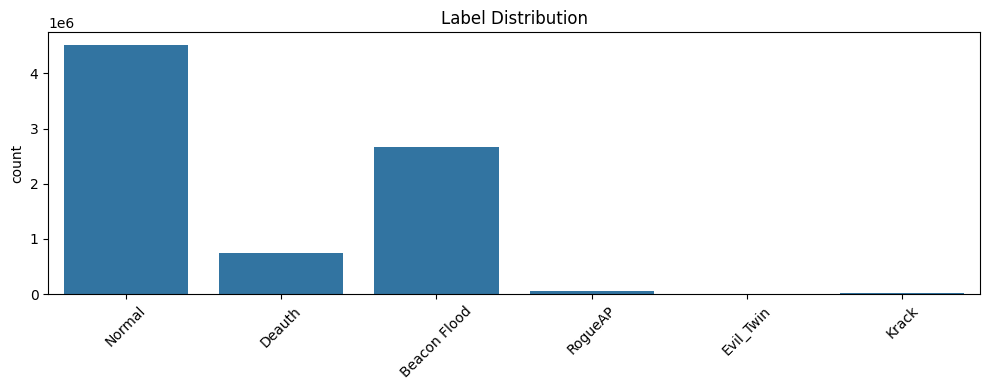

In [ ]:
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Path to dataset
filepath = "/root/.cache/kagglehub/datasets/justiceadeboye/wpa3-dataset/versions/1/wpa3_dataset.csv"

def process_dataset(filepath, chunk_size=10000):
    print("📂 Inspecting dataset...")

    # Step 1: Determine numeric columns and gather all unique labels
    sample_chunk = pd.read_csv(filepath, nrows=1000)
    if 'Label' not in sample_chunk.columns:
        raise ValueError("Dataset must contain 'Label' column.")

    feature_cols = [col for col in sample_chunk.columns if col != 'Label']

    # 🔍 Collect all unique labels from the full dataset
    print("🔎 Collecting unique labels...")
    unique_labels = set()
    for chunk in pd.read_csv(filepath, chunksize=chunk_size, usecols=['Label']):
        chunk = chunk.dropna(subset=['Label'])
        chunk_labels = chunk['Label'].astype(str).unique()
        unique_labels.update(chunk_labels)

    encoder = LabelEncoder()
    encoder.fit(sorted(list(unique_labels)))
    print(f"✅ Label classes: {encoder.classes_}")

    # 🔬 Analyze numeric columns and null columns (from 3 chunks max)
    numeric_columns = set()
    null_columns = set()
    for i, chunk in enumerate(pd.read_csv(filepath, chunksize=chunk_size, low_memory=False)):
        chunk = chunk.loc[:, ~chunk.columns.str.contains('^Unnamed')]
        chunk = chunk.replace("?", np.nan)
        chunk = chunk.dropna(subset=['Label'])

        for col in chunk.columns:
            if col == 'Label':
                continue
            if chunk[col].isnull().mean() >= 0.9:
                null_columns.add(col)
                continue
            try:
                pd.to_numeric(chunk[col].dropna(), errors='raise')
                numeric_columns.add(col)
            except:
                pass
        if i >= 2:
            break

    valid_columns = sorted(list(numeric_columns - null_columns))
    print(f"📉 Dropping {len(null_columns)} mostly-null columns")
    print(f"🔢 Keeping {len(valid_columns)} numeric columns")

    # 🧪 Process all chunks
    X_data, y_data = [], []
    for chunk in pd.read_csv(filepath, chunksize=chunk_size, low_memory=False):
        chunk = chunk.loc[:, ~chunk.columns.str.contains('^Unnamed')]
        chunk = chunk.replace("?", np.nan)
        chunk = chunk.dropna(subset=['Label'])

        # Filter valid labels
        chunk = chunk[chunk['Label'].astype(str).isin(encoder.classes_)]
        if chunk.empty:
            continue

        # Extract and encode labels
        chunk_y = encoder.transform(chunk['Label'].astype(str))

        # Clean and convert features
        chunk_X = chunk[valid_columns].copy()
        for col in chunk_X.columns:
            chunk_X[col] = pd.to_numeric(chunk_X[col], errors='coerce')

        # Impute missing with column means (fallback 0 if entire column is NaN)
        chunk_X = chunk_X.fillna(chunk_X.mean()).fillna(0)

        X_data.append(chunk_X.values)
        y_data.append(chunk_y)
        gc.collect()

    # 🧱 Stack final dataset
    X = np.vstack(X_data)
    y = np.concatenate(y_data)
    print(f"✅ Final dataset shape: X = {X.shape}, y = {y.shape}")
    return X, y, encoder, valid_columns

# 🧹 Run preprocessing
X, y, label_encoder, feature_names = process_dataset(filepath)

# 📊 Visualize label distribution
plt.figure(figsize=(10, 4))
sns.countplot(x=label_encoder.inverse_transform(y))
plt.title("Label Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:

# 🧠 Define DIRL Model (using FrEIA)
import torch
import torch.nn as nn
import FrEIA.framework as Ff
import FrEIA.modules as Fm

# Subnetwork constructor for coupling blocks
def subnet_fc(in_channels, out_channels):
    return nn.Sequential(
        nn.Linear(in_channels, 512),
        nn.ReLU(),
        nn.Linear(512, out_channels)
    )

class DIRLNet(nn.Module):
    def __init__(self, dims):
        super(DIRLNet, self).__init__()
        self.dims = dims
        nodes = [Ff.InputNode(dims, name='input')]
        for _ in range(4):
            nodes.append(Ff.Node(nodes[-1], Fm.GLOWCouplingBlock, {
                'clamp': 2.0,
                'subnet_constructor': subnet_fc
            }, name='coupling'))
            nodes.append(Ff.Node(nodes[-1], Fm.PermuteRandom, {'seed': 42}, name='permute'))
        nodes.append(Ff.OutputNode(nodes[-1], name='output'))
        self.model = Ff.ReversibleGraphNet(nodes, verbose=False)

    def forward(self, x):
        return self.model(x)


In [ ]:
# 🚀 Train Model + 🧪 Evaluate & Save Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import joblib

# Prepare data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train).float()), batch_size=512, shuffle=True)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DIRLNet(dims=X.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
# Training loop with gradient clipping
model.train()
for epoch in range(10):
    total_loss = 0
    for batch in train_loader:
        x_batch = batch[0].to(device)
        z, _ = model(x_batch)  # Discard log-determinant
        loss = torch.mean(z ** 2)  # L2 norm in latent space
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch + 1}: Loss = {total_loss / len(train_loader):.4f}")


# Evaluation: extract latent test features
model.eval()
with torch.no_grad():
    z_test_tensor, _ = model(torch.tensor(X_test).float().to(device))
z_test = z_test_tensor.cpu().numpy()

# Fit classifier in latent space
clf = LogisticRegression(max_iter=1000)
clf.fit(z_test, y_test)
preds = clf.predict(z_test)

# Save model and classifier
torch.save(model.state_dict(), "dirl_model.pt")
joblib.dump(clf, "latent_classifier.pkl")
joblib.dump(scaler, "scaler.pkl")
print("✅ Model and classifier saved.")


Epoch 1: Loss = 0.0738
Epoch 2: Loss = 0.0000
Epoch 3: Loss = 0.0000
Epoch 4: Loss = 0.0000
Epoch 5: Loss = 0.0000
Epoch 6: Loss = 0.0000
Epoch 7: Loss = 0.0000
Epoch 8: Loss = 0.0000
Epoch 9: Loss = 0.0000
Epoch 10: Loss = 0.0000
✅ Model and classifier saved.


<ipython-input-6-ccf43d085a45>:29: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


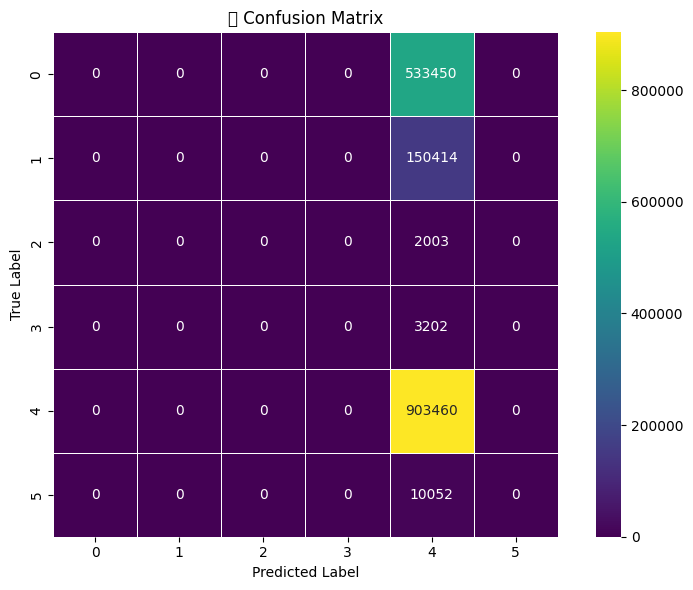

In [ ]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Load your trained classifier
clf = joblib.load("latent_classifier.pkl")

# Recover original string labels
le = LabelEncoder()
le.fit(y)
label_names = le.classes_
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict using classifier
preds = clf.predict(z_test)

# Create confusion matrix
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=label_names, yticklabels=label_names,
            square=True, cbar=True, linewidths=0.5)

plt.title("📊 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


<ipython-input-8-bc5325bc4cca>:19: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-bc5325bc4cca>:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


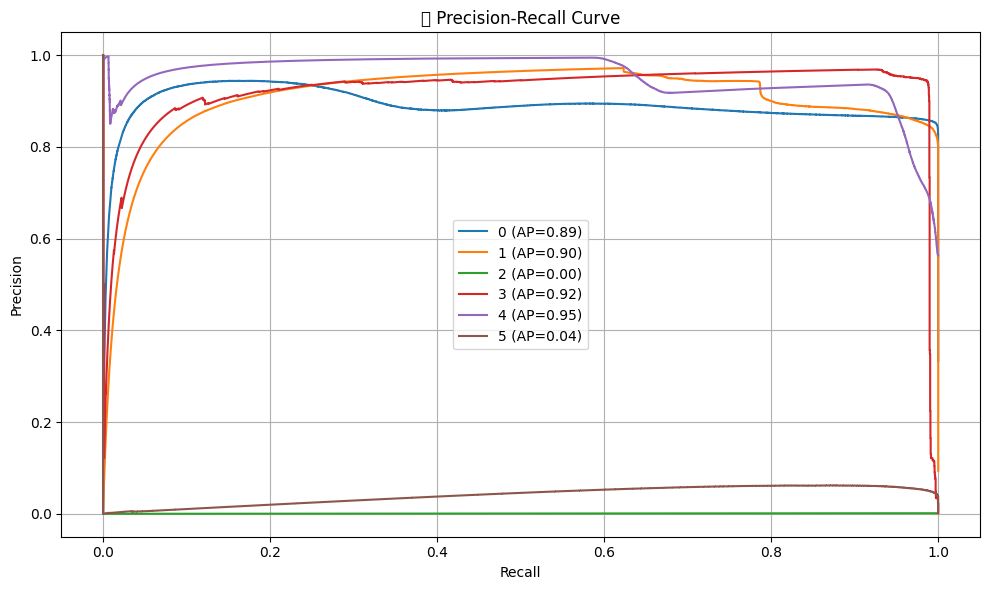

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binarize true labels
y_test_bin = label_binarize(y_test, classes=range(len(label_names)))
probs = clf.predict_proba(z_test)

plt.figure(figsize=(10, 6))
for i, class_name in enumerate(label_names):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], probs[:, i])
    plt.plot(rec, prec, label=f"{class_name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("📈 Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-9-1f62b2828d3f>:15: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


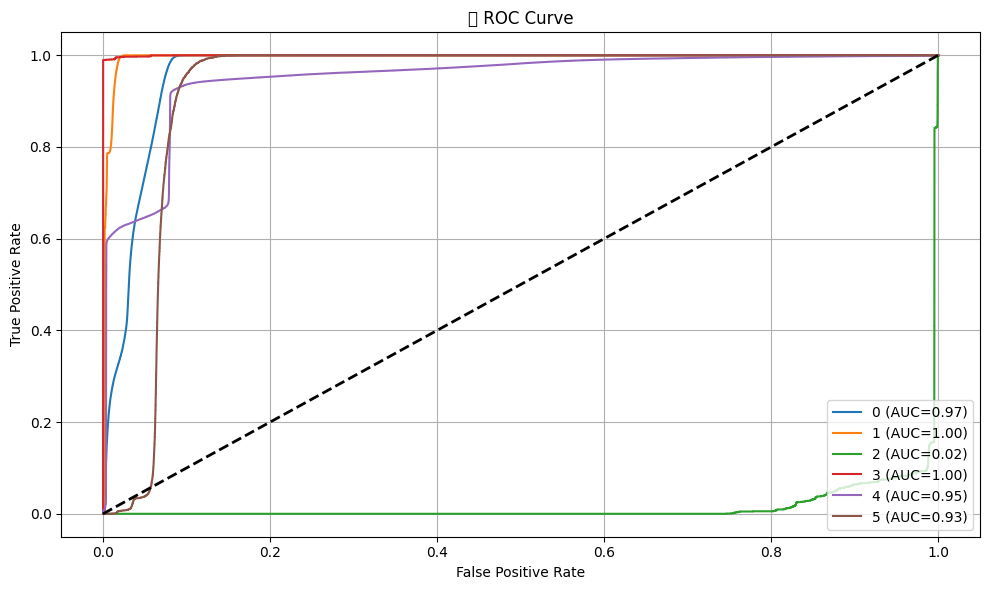

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))
for i, class_name in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("📉 ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-29-e3a2fe41284e>:68: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


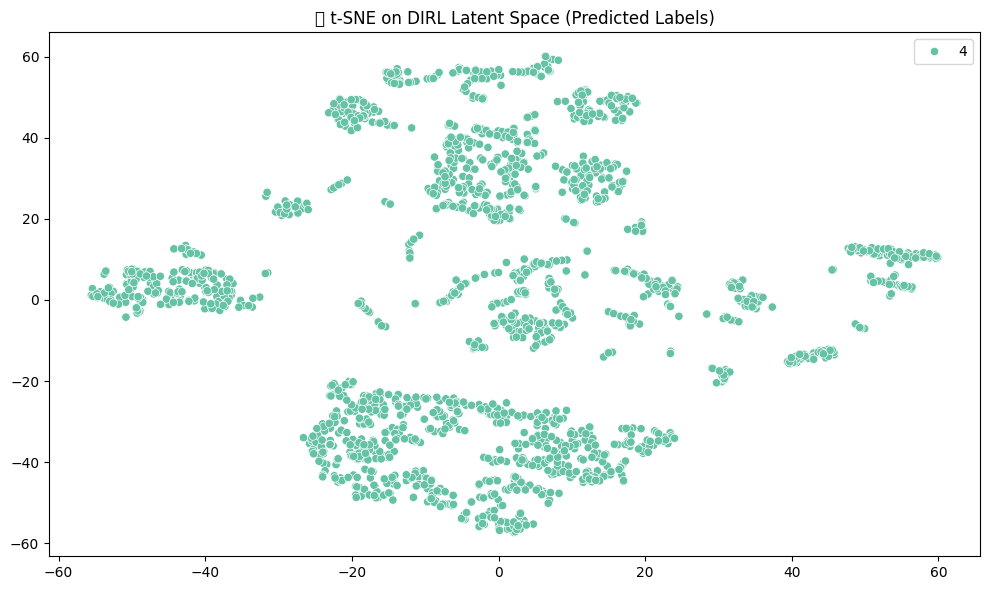

In [29]:
import torch
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 🧠 Rebuild the DIRL model class
import FrEIA.framework as Ff
import FrEIA.modules as Fm
import torch.nn as nn

def subnet_fc(in_ch, out_ch):
    return nn.Sequential(
        nn.Linear(in_ch, 512),
        nn.ReLU(),
        nn.Linear(512, out_ch)
    )

class DIRLNet(nn.Module):
    def __init__(self, dims):
        super(DIRLNet, self).__init__()
        self.dims = dims
        nodes = [Ff.InputNode(dims, name='input')]
        for _ in range(4):
            nodes.append(Ff.Node(nodes[-1], Fm.GLOWCouplingBlock, {
                'clamp': 2.0,
                'subnet_constructor': subnet_fc
            }, name='coupling'))
            nodes.append(Ff.Node(nodes[-1], Fm.PermuteRandom, {'seed': 42}, name='permute'))
        nodes.append(Ff.OutputNode(nodes[-1], name='output'))
        self.model = Ff.ReversibleGraphNet(nodes, verbose=False)

    def forward(self, x):
        return self.model(x)

# 📦 Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_test.shape[1]  # ⚠️ Assumes X_test is already loaded
dirl_model = DIRLNet(input_dim).to(device)
dirl_model.load_state_dict(torch.load('/content/dirl_model.pt', map_location=device))
dirl_model.eval()

# 🔁 Inference on test data
X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    z, _ = dirl_model(X_tensor)
z_np = z.cpu().numpy()

# 📥 Load classifier
clf = joblib.load('/content/latent_classifier.pkl')

# 🏷️ Predict labels
y_pred = clf.predict(z_np)

# ⚡ Subsample
max_samples = 2000
z_subset = z_np[:max_samples]
y_subset = y_pred[:max_samples]

# 🧬 t-SNE(t-distributed stochastic neighbor embedding)
z_tsne = TSNE(n_components=2, random_state=42).fit_transform(z_subset)

# 📊 Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=z_tsne[:, 0], y=z_tsne[:, 1], hue=y_subset, palette='Set2')
plt.title("🧬 t-SNE on DIRL Latent Space (Predicted Labels)")
plt.tight_layout()
plt.show()


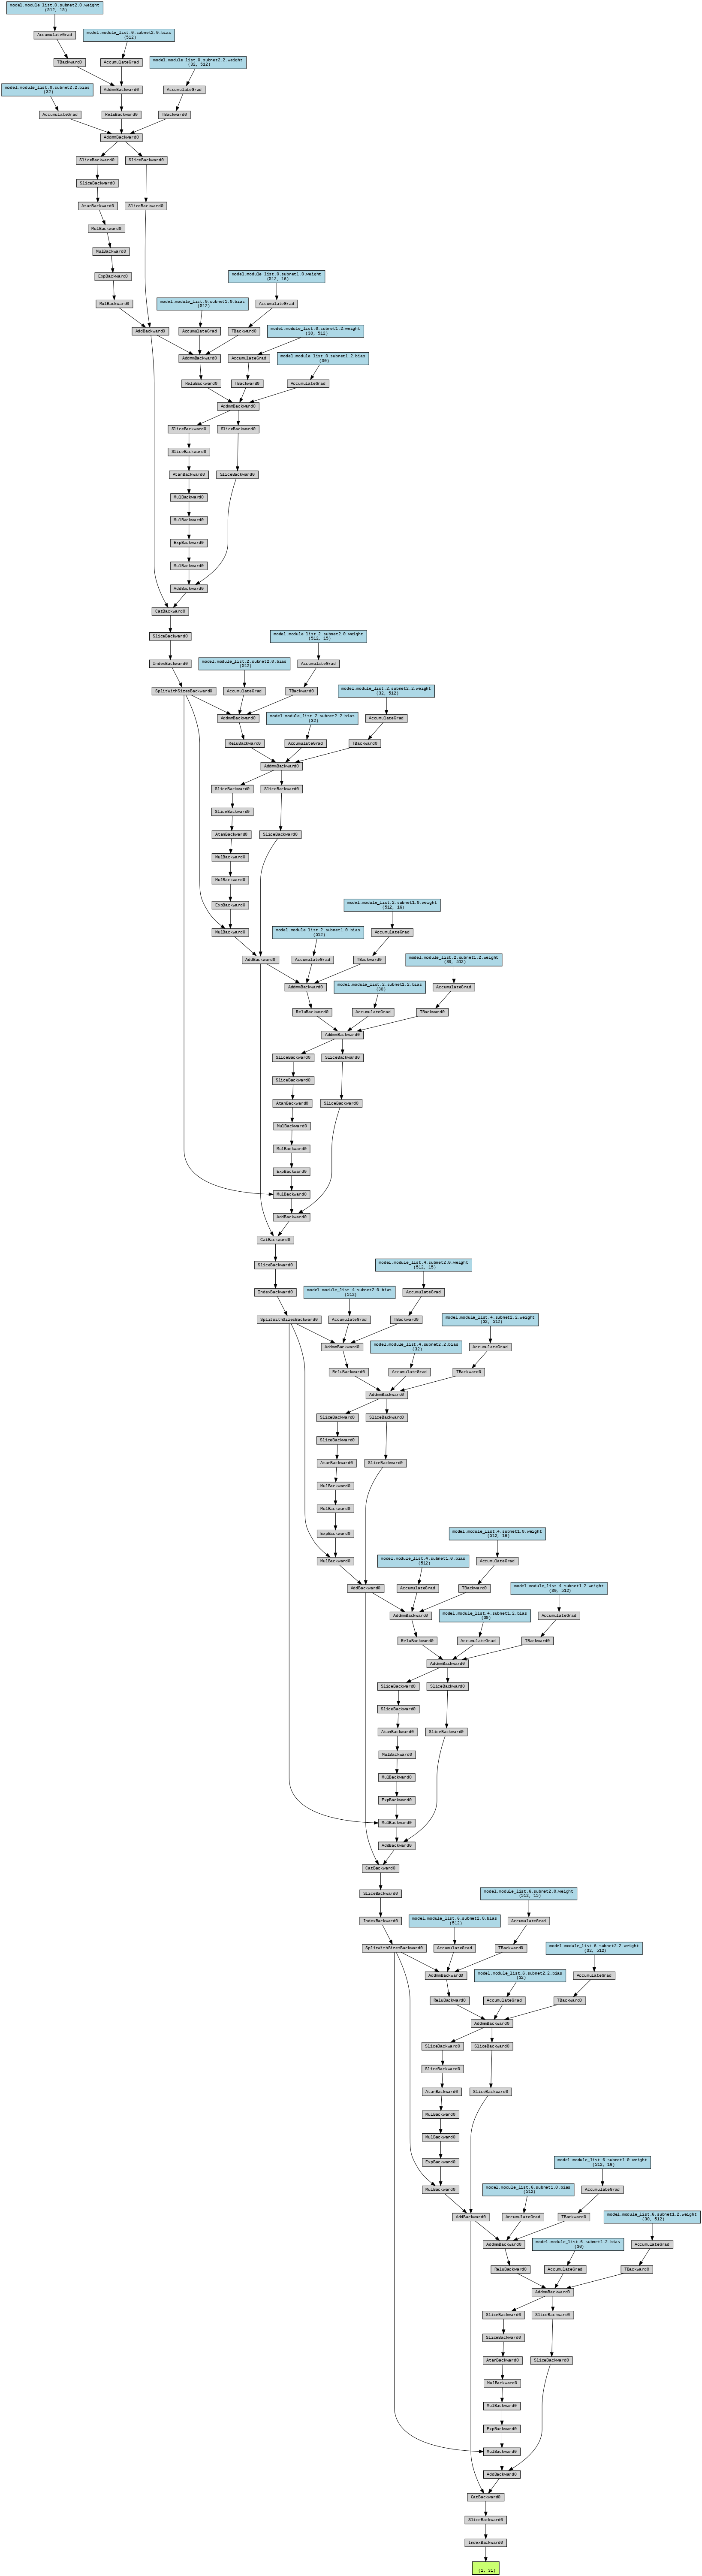

In [ ]:
from torchviz import make_dot
from IPython.display import Image, display
import torch

# Generate a sample input
sample_input = torch.randn(1, X.shape[1]).to(device)
z, _ = model(sample_input)

# Generate and save the grapha
dot = make_dot(z, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render("dirl_model_graph", cleanup=True)

# Display inline
display(Image(filename="dirl_model_graph.png"))


<ipython-input-21-448f6dca410b>:25: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


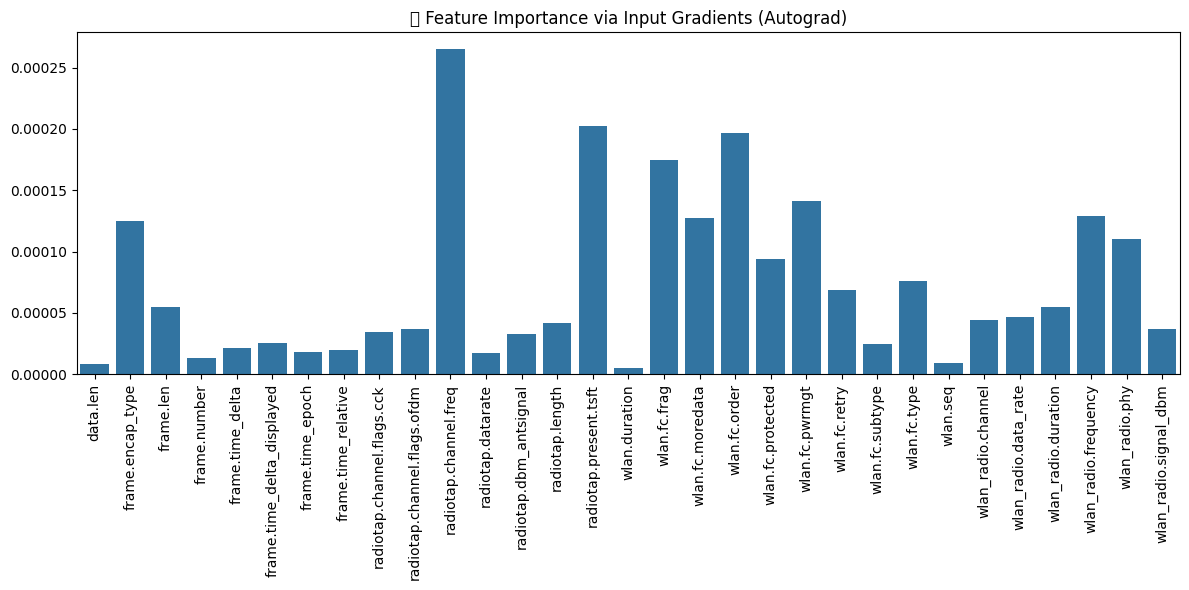

In [ ]:
# 🔥 Feature Importance via Autograd
sample_size = 128  # Small batch to avoid OOM
X_sample = X_test[:sample_size]
X_sample_tensor = torch.tensor(X_sample, dtype=torch.float32, requires_grad=True).to(device)

model.eval()

# Forward pass (model returns tuple)
latent = model(X_sample_tensor)[0]  # Get latent output

# Use scalar loss to enable gradient tracing
loss = latent.norm()

# Explicitly compute gradients w.r.t. input
grads = torch.autograd.grad(outputs=loss, inputs=X_sample_tensor)[0]

# Aggregate gradients across samples
feature_importance = grads.abs().mean(dim=0).cpu().numpy()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_names, y=feature_importance)
plt.xticks(rotation=90)
plt.title("🔥 Feature Importance via Input Gradients (Autograd)")
plt.tight_layout()
plt.show()


In [ ]:
# 🧹 Cleanup
del model, clf, z_test, X_train, X_test
import gc
gc.collect()
torch.cuda.empty_cache()
print("🧼 Cleanup complete.")
